# Stock Price Prediction using Regression

Objective :The goal of this assignment is to apply the knowledge of regression modeling to predict the stock prices of a company. Students will use historical stock data to train, validate, and test a regression model that forecasts future prices based on features like date, opening price, high price, low price, and volume.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')


1. Data Collection: - Download historical stock data for a chosen company (e.g., Google, Apple) from a source like Yahoo Finance, Quandl, or Alpha Vantage. Ensure that the dataset contains columns such as: - Date - Open price - High price - Low price - Close price - Adjusted close price - Volume

In [4]:
!pip install yfinance

In [4]:
import yfinance as yf

# Define the ticker symbol for the company
ticker_symbol = 'GOOG'

# Re-download historical stock data
# Setting auto_adjust=False ensures both 'Close' and 'Adj Close' columns are present if auto_adjust not given 'Adj Close' column is absent.
data_stocks = yf.download(ticker_symbol, start='2015-01-01', end='2024-12-31', auto_adjust=False)

# If columns are a MultiIndex (e.g., ('Close', 'GOOG')), flatten them. Multiindex means at the first level (e.g., 'Close', 'Adj Close') is usually present
# and on second level 'GOOG' is present which is not required so below code chekcing for multiindex and if its present then dropping second level (1) first level is 0
if isinstance(data_stocks.columns, pd.MultiIndex):
  data_stocks.columns = data_stocks.columns.droplevel(1)

# Display the first few rows of the cleaned data
display(data_stocks.head())

# Display info to confirm 'Adj Close' is now present and column names are simplified
data_stocks.info()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,25.955561,26.168653,26.490770,26.133251,26.378078,28951268
2015-01-05,25.414501,25.623152,26.144720,25.582764,26.091366,41196796
2015-01-06,24.825466,25.029282,25.738087,24.983908,25.679497,57998800
2015-01-07,24.782934,24.986401,25.292759,24.914099,25.280592,41301082
2015-01-08,24.861078,25.065184,25.105074,24.482782,24.831326,67071641


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2515 non-null   float64
 1   Close      2515 non-null   float64
 2   High       2515 non-null   float64
 3   Low        2515 non-null   float64
 4   Open       2515 non-null   float64
 5   Volume     2515 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.5 KB


2. Exploratory Data Analysis (EDA):
- Perform EDA to understand the data:
- Check for missing values and handle them appropriately.
- Plot trends of stock prices over time using matplotlib or seaborn.
- Generate summary statistics (mean, median, etc.) of the dataset.
- Create scatter plots of features like volume, open price, and high price against the closing price to visualize relationships.

In [6]:
# checking for missing values:--- no missing values found
data_stocks.isnull().sum()

,0
Price,
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [7]:
# Descriptive statistics: Generate summary statistics (mean, median, etc.) of the dataset.

data_stocks.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,82.095203,82.749663,83.586875,81.881540,82.697528,3.078201e+07
std,44.187048,44.509109,44.991332,44.037177,44.486946,1.536687e+07
min,24.360075,24.560070,24.730902,24.311253,24.664783,6.809800e+06
25%,46.094812,46.473249,46.715250,46.176624,46.486500,2.122600e+07
50%,64.075447,64.601501,64.965500,63.950001,64.473000,2.702400e+07
75%,119.965099,120.950001,122.215000,120.074997,120.965000,3.569100e+07
max,197.252579,198.160004,202.880005,196.690002,198.529999,2.232980e+08


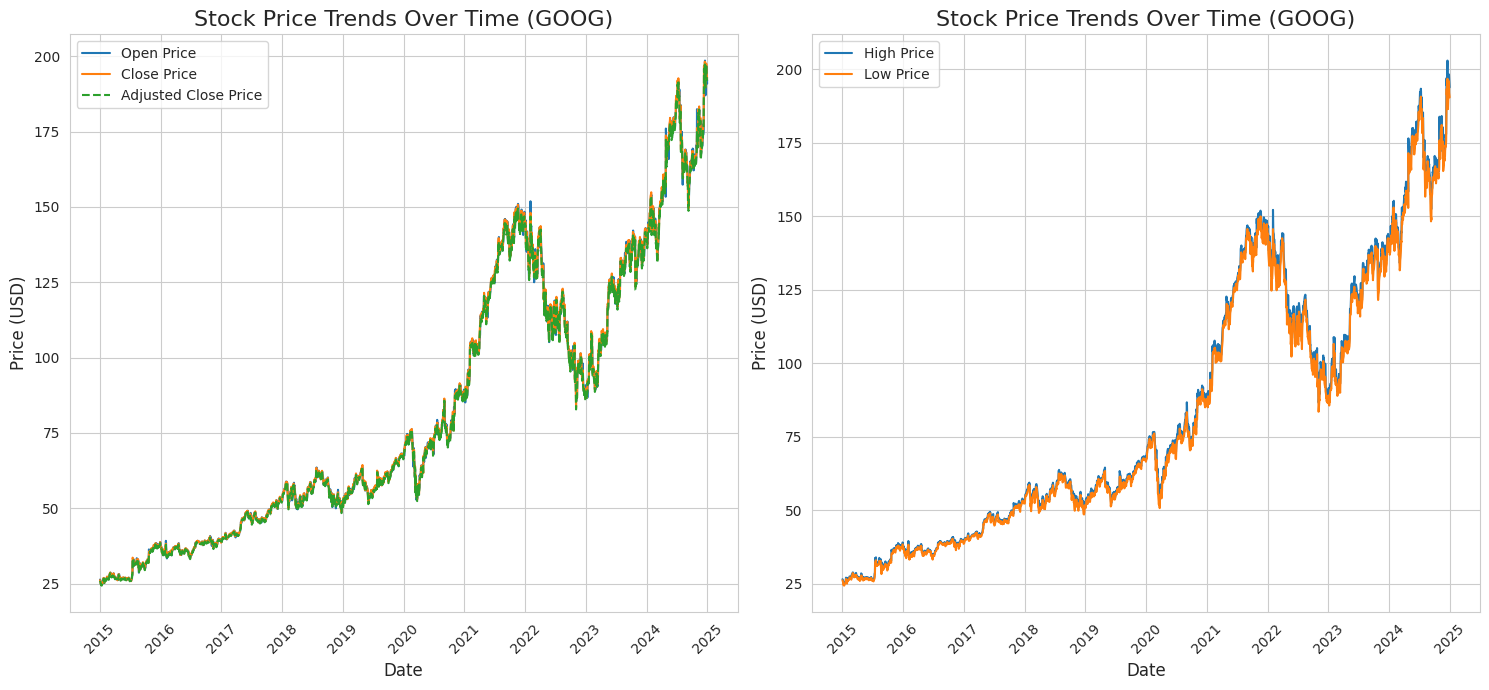

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
plt.figure(figsize=(15, 7))

# Plotting the different price trends
plt.subplot(1,2,1)

plt.plot(data_stocks['Open'], label='Open Price')
plt.plot(data_stocks['Close'], label='Close Price')
plt.plot(data_stocks['Adj Close'], label='Adjusted Close Price', linestyle='--')

plt.title('Stock Price Trends Over Time (GOOG)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.plot(data_stocks['High'], label='High Price')
plt.plot(data_stocks['Low'], label='Low Price')

# Adding titles and labels
plt.title('Stock Price Trends Over Time (GOOG)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)

# Improve layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

In [9]:
# @title
"""  Using Plotly to create the candlestick chart: for knowledge purpose understanding.
import plotly.graph_objects as go

# Create the candlestick chart
fig = go.Figure(data=[
go.Candlestick(
        x=data_stocks.index,
        open=data_stocks['Open'],
        high=data_stocks['High'],
        low=data_stocks['Low'],
        close=data_stocks['Close'],
        name='Stock Price'
    )
])

# Customize the layout
fig.update_layout(
    title={
        'text': 'Stock Price Candlestick Chart (GOOG)',
        'yref': 'container', # ensure title is placed relative to plot area
        'yanchor': 'top',
        'y': 0.95, # Position of the title relative to the top of the plot
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    xaxis_rangeslider_visible=False, # Hide the range slider for a cleaner look
    height=600, # Adjust height for better visibility
    template='plotly_white' # Use a clean white template
)

# Add hover information
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey',)
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')

# Display the plot
fig.show()
"""

"  Using Plotly to create the candlestick chart: for knowledge purpose understanding.\nimport plotly.graph_objects as go\n\n# Create the candlestick chart\nfig = go.Figure(data=[\ngo.Candlestick(\n        x=data_stocks.index,\n        open=data_stocks['Open'],\n        high=data_stocks['High'],\n        low=data_stocks['Low'],\n        close=data_stocks['Close'],\n        name='Stock Price'\n    )\n])\n\n# Customize the layout\nfig.update_layout(\n    title={\n        'text': 'Stock Price Candlestick Chart (GOOG)',\n        'yref': 'container', # ensure title is placed relative to plot area\n        'yanchor': 'top',\n        'y': 0.95, # Position of the title relative to the top of the plot\n        'x': 0.5,\n        'xanchor': 'center'\n    },\n    xaxis_title='Date',\n    yaxis_title='Price (USD)',\n    xaxis_rangeslider_visible=False, # Hide the range slider for a cleaner look\n    height=600, # Adjust height for better visibility\n    template='plotly_white' # Use a clean white t

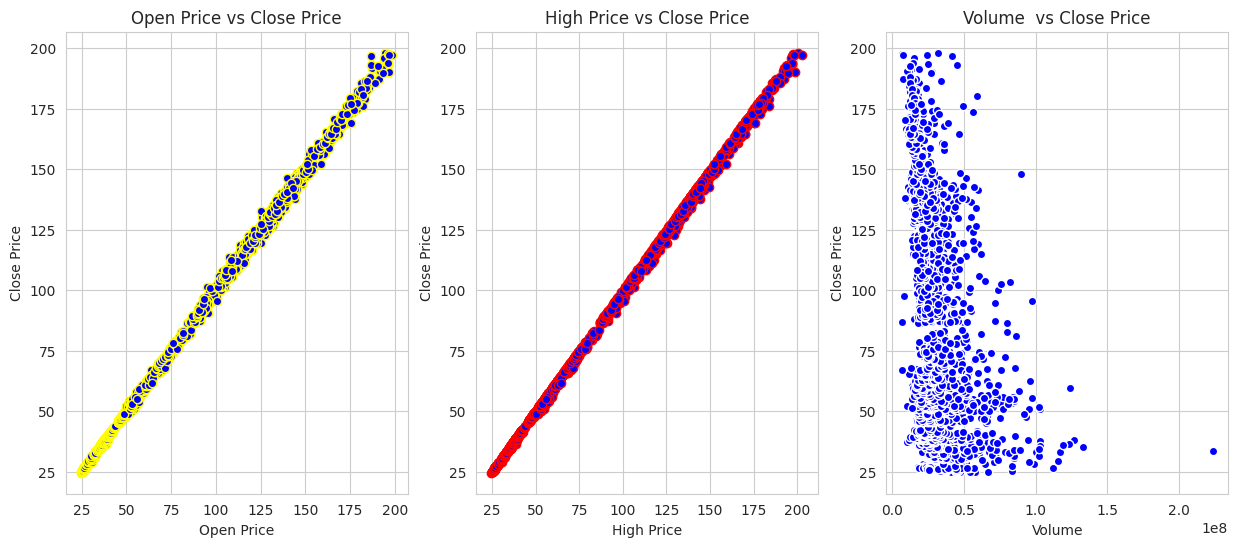

In [10]:
# Scatter plot to check relation between open price ,high price and Volume with Closing price
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.scatter(data_stocks['Open'],data_stocks['Close'], color= 'blue' ,edgecolors= 'yellow' )
plt.title('Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')

plt.subplot(1,3,2)
plt.scatter(data_stocks['High'],data_stocks['Close'], color= 'blue' ,edgecolors= 'red' )
plt.title('High Price vs Close Price')
plt.xlabel('High Price')
plt.ylabel('Close Price')

plt.subplot(1,3,3)
plt.scatter(data_stocks['Volume'],data_stocks['Close'], color= 'blue' ,edgecolors= 'white' )
plt.title('Volume  vs Close Price')
plt.xlabel('Volume')
plt.ylabel('Close Price')

plt.show()

3. Feature Selection:
- Identify features that could be useful in predicting the stock price.
- Justify your choice of features based on correlation analysis or visual inspection.
- (Optional) Try to create new features like moving averages or price changes to improve the model.

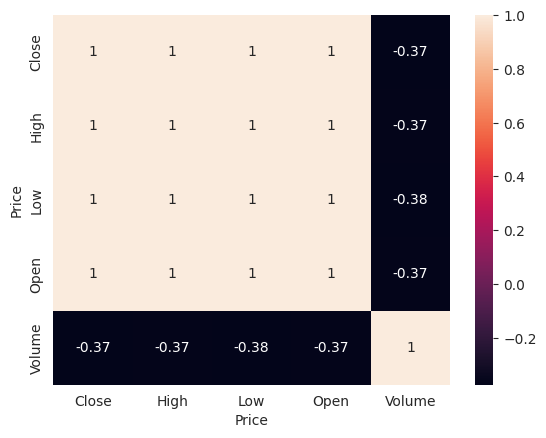

In [11]:
# Other than Volume  other features seems correlated and Volume shows less negative correlation with other features.
data_stocks.drop(['Adj Close'],axis = 1,inplace = True)

plt.figure()
sns.heatmap(data_stocks.corr(),annot = True)
plt.show()


In [12]:
#Try to create new features like moving averages or price changes to improve the model. MA10 indicates last 10 closing price avg is taken same for 50 and 200
data_stocks['MA10']= data_stocks['Close'].rolling(10).mean()
data_stocks['MA50']= data_stocks['Close'].rolling(50).mean()
data_stocks['MA200']= data_stocks['Close'].rolling(200).mean()

# dropiing initial rows as for moving average values as 'nan' is present so to remove those rows dropna is used
data_stocks.dropna(inplace = True)

data_stocks.head(100)

Price,Close,High,Low,Open,Volume,MA10,MA50,MA200
Date,,,,,,,,
2015-10-16,33.110001,33.248501,32.860001,33.205502,32222000,32.43055,31.52762,28.376283
2015-10-19,33.305000,33.341000,32.979000,33.058998,29546000,32.55370,31.55842,28.411965
2015-10-20,32.514000,33.236000,32.209751,33.202000,49964000,32.57790,31.57497,28.446419
2015-10-21,32.130501,32.793499,32.086498,32.707500,35822000,32.57915,31.55680,28.481925
2015-10-22,32.589500,32.889999,32.200500,32.334999,81420000,32.64230,31.54903,28.519940
...,...,...,...,...,...,...,...,...
2016-03-04,35.544498,35.824501,35.300999,35.749500,39442000,35.35715,35.88387,32.828277
2016-03-07,34.757999,35.404549,34.345001,35.345001,59702000,35.30065,35.82903,32.867250
2016-03-08,34.698502,35.189499,34.266998,34.429501,41526000,35.29125,35.77269,32.905115


4. Data Preprocessing:
- Split the data into training and testing sets.
- Scale the features using StandardScaler or MinMaxScaler if necessary.
- Ensure that the dates are properly formatted for time-series forecasting (if applicable).

In [13]:
X = data_stocks.drop(['Close'],axis =1)
Y = data_stocks['Close']

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)



5. Model Building:
- Choose a regression algorithm (Linear Regression, Ridge, Lasso, etc.) to build your model.
- Implement the regression model using Python’s scikit-learn.
- Train the model using your training dataset.

In [14]:
lr =LinearRegression()
lr

LinearRegression()

In [15]:
# Prpearing Linear regression Model training the model and then applying regularization after checking performance metrics
lr.fit(x_train,y_train)

y_pred_train =lr.predict(x_train)
y_pred_test = lr.predict(x_test)

# Performance Metrics
print('Performance Metrics')
mse_train = mean_squared_error(y_train,y_pred_train)
mse_test = mean_squared_error(y_test,y_pred_test)
mae_test = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse_test)
r2_score_train = r2_score(y_train,y_pred_train)
r2_score_test = r2_score(y_test,y_pred_test)

print(f'Model Coefficients of Regression - Linear Regression  : {lr.coef_}')
print(f'Model Intercept - Linear Regression: {lr.intercept_}')
print('*'* 25)
print(f'MAE_test : {mae_test:.4f}')
print('*'* 25)
print(f'MSE_train :{mse_train:.4f}')
print(f'MSE_test : {mse_test:.4f}')
print('*'* 25)
print(f'r2_score_train :{r2_score_train:.4f}')
print(f'r2_score_test : {r2_score_test:.4f}')
print(f'Root Mean square Error : {rmse:.4f}')

Performance Metrics
Model Coefficients of Regression - Linear Regression  : [ 3.16369648e+01  3.73846567e+01 -2.68134805e+01  1.08454543e-02
  1.40466221e+00 -3.02640268e-01  7.10973774e-02]
Model Intercept - Linear Regression: 88.01644079113625
*************************
MAE_test : 0.4173
*************************
MSE_train :0.3428
MSE_test : 0.3836
*************************
r2_score_train :0.9998
r2_score_test : 0.9998
Root Mean square Error : 0.6193


Observations:
Since mse_train  < mse_test and difference between r2_score train and test is 0 or less than 0.1 model is better but need to check for slight overfitting by applying regularization techniques we can verify


6. Model Evaluation:
- Evaluate the model’s performance using appropriate metrics such as:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)
- Analyze the model’s residuals (the difference between predicted and actual values).

In [16]:
# Applying Ridge regularization technique
ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(x_train,y_train)

y_pred_train_reg = ridge_model.predict(x_train)
y_pred_test_reg = ridge_model.predict(x_test)


print("*" * 50)
print("Mean Square Error (mse_train_reg) : ", mean_squared_error(y_train,y_pred_train_reg))
print("Mean Square Error (mse_test_reg) : ", mean_squared_error(y_test,y_pred_test_reg))
print("*" * 50)
print(f"R2_score train :  {r2_score(y_train,y_pred_train_reg):.4f}")
print(f"R2_score Test :  {r2_score(y_test,y_pred_test_reg):.4f}")

mae_test_reg = mean_absolute_error(y_test,y_pred_test_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test,y_pred_test_reg))
print("*" * 50)
print(f'MAE_test : {mae_test_reg:.4f}')
print(f'rmse_reg : {rmse_reg:.4f}')

**************************************************
Mean Square Error (mse_train_reg) :  0.628025348396396
Mean Square Error (mse_test_reg) :  0.6297548568828707
**************************************************
R2_score train :  0.9997
R2_score Test :  0.9997
**************************************************
MAE_test : 0.5354
rmse_reg : 0.7936


Observation : after applying ridge regularization technique there is slight increse in MSE indicating variance might have reduced still model is better fit as r2 score is good.

7. Model Improvement:
- Based on the evaluation metrics, try to improve the model by:
- Testing different regression algorithms (e.g., Decision Tree Regressor, Random Forest Regressor). - Tuning hyperparameters using GridSearchCV or RandomizedSearchCV.
- (Optional) Adding lagged features or using moving averages for time-series prediction.

In [17]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Define the number of splits for K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
# We'll use the original X and y before the train-test split for this demonstration
cv_scores = cross_val_score(model, X, Y, cv=kf, scoring='r2')

print("Cross-validation R2 scores:", np.round(cv_scores,4))
print("Mean R2 score:", np.round(cv_scores.mean(),4))
print("Standard deviation of R2 scores:", np.round(cv_scores.std(),4))

Cross-validation R2 scores: [0.9998 0.9998 0.9998 0.9998 0.9998]
Mean R2 score: 0.9998
Standard deviation of R2 scores: 0.0


### Random Forest Regressor with GridSearchCV for Hyperparameter Tuning
Grid search Cv technique used to determine best hyper parameter which needs to pass to RandomForestRgressor Algo parameters like n_esitimators(no of decision trees)Max_depth (depth or level of tree) min_sample_split(min no of samples required to split an internal node) min_sample_leaf(min no of samples required to be at a leaf node)

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=KFold(n_splits=3, shuffle=True, random_state=42),
                           n_jobs=-1, verbose=2, scoring='r2')

grid_search.fit(x_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R2 score found: ", grid_search.best_score_)

# Get the best model
best_rf_model = grid_search.best_estimator_


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best R2 score found:  0.9995851002692792


After finding the best parameters, let's evaluate the performance of the best `RandomForestRegressor` model on both the training and test sets.

In [19]:
# Make predictions with the best Random Forest model
y_pred_train_rf = best_rf_model.predict(x_train)
y_pred_test_rf = best_rf_model.predict(x_test)

# Calculate performance metrics
mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
mse_test_rf = mean_squared_error(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_rf = np.sqrt(mse_test_rf)
r2_score_train_rf = r2_score(y_train, y_pred_train_rf)
r2_score_test_rf = r2_score(y_test, y_pred_test_rf)

print('Random Forest Regressor Performance Metrics')
print('*'* 50)
print(f'MAE_test : {mae_test_rf:.4f}')
print('*'* 50)
print(f'MSE_train :{mse_train_rf:.4f}')
print(f'MSE_test : {mse_test_rf:.4f}')
print('*'* 50)
print(f'r2_score_train :{r2_score_train_rf:.4f}')
print(f'r2_score_test : {r2_score_test_rf:.4f}')
print(f'Root Mean square Error : {rmse_rf:.4f}')

Random Forest Regressor Performance Metrics
**************************************************
MAE_test : 0.5393
**************************************************
MSE_train :0.1662
MSE_test : 0.6424
**************************************************
r2_score_train :0.9999
r2_score_test : 0.9996
Root Mean square Error : 0.8015


8. Conclusion:
- Summarize the findings of your model:
- What features were most influential in predicting stock prices?
- How accurate is the model?
- What could be done to improve the model’s performance further?

Final Observations:
1. LinearRegression Model is having low MSE but with good r2 score indicating model is better fit.
2. There are price features like open,high,low are correlated. also Close which is used as target variable , value of close is known at the end of the day so instead of same day close we might need to consider next day close as target which can better train model as all dataset forsame day is available and accordingly next day what is the impact can be determined.
3. After applying Ridge regularization technique there is slight increase in MSE indicating variance might have reduced bias- vriance trade off is achieved and  model is better fit as r2 score is good.
4. Tried with RandomforestRegressor model with GridsearchCV hyperparameter tuning which is showing better performance by reducing MSE and achieving goor r2 score.

